In [ ]:
# import necessary libraries

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import pandas as pd
import scipy.stats as ss
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.manifold import TSNE

import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Random seeds for reproducibility

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Default parameters
NOISE_DIM      = 128
G_LR       = 0.0003
D_LR       = 0.0001
N_EPOCHS   = 100
BATCH_SIZE = 256

Using device: cuda


In [9]:
# Load all data into the datafraem from colab section folder
# since file is too large to be uploaded to github

df_mon = pd.read_csv("/content/Monday-WorkingHours.pcap_ISCX.csv")

df_tues = pd.read_csv("/content/Tuesday-WorkingHours.pcap_ISCX.csv")

df_wed = pd.read_csv("/content/Wednesday-workingHours.pcap_ISCX.csv")

df_thur_1 = pd.read_csv("/content/Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv")

df_thur_2 = pd.read_csv("/content/Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv")

df_frd_1 = pd.read_csv("/content/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv")

df_frd_2 = pd.read_csv("/content/Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv")

df_frd_3 = pd.read_csv("/content/Friday-WorkingHours-Morning.pcap_ISCX.csv")

In [10]:
# Get all the dataframes and standardize the column names before merging all
data_files = [df_mon, df_tues, df_wed, df_thur_1,
              df_thur_2, df_frd_1, df_frd_2, df_frd_3]

# remove any spaces before and after column name
for df in data_files:
    df.columns = df.columns.str.strip()

# Merge all into one dataframe
df_raw = pd.concat(data_files, ignore_index=True, sort=False)
print(f"Combined dataset shape: {df_raw.shape} \n")
print(f"Label distribution:\n{df_raw['Label'].value_counts()}")

Combined dataset shape: (1398438, 79) 

Label distribution:
Label
BENIGN                        1103983
PortScan                       158930
DDoS                           128027
FTP-Patator                      3159
Bot                              1966
Web Attack � Brute Force         1507
Web Attack � XSS                  652
DoS slowloris                     153
Infiltration                       36
Web Attack � Sql Injection         21
Name: count, dtype: int64


In [ ]:
# Preview single file
df_raw.sample(10)

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
180370,443,169476,10,5,896,1471,645,0,89.600000,201.103180,...,32.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
17201,443,30698055,2,1,12,0,6,6,6.000000,0.000000,...,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
69732,443,10071880,7,8,1157,4686,517,0,165.285714,237.365200,...,20.0,125591.0,0.0,125591.0,125591.0,9946286.0,0.0,9946286.0,9946286.0,BENIGN
1190949,8087,56,1,1,2,6,2,2,2.000000,0.000000,...,24.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,PortScan
223977,53,122757,1,1,58,156,58,58,58.000000,0.000000,...,32.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
1386812,53,236,2,2,64,224,32,32,32.000000,0.000000,...,32.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
14463,53,25333,1,1,58,186,58,58,58.000000,0.000000,...,32.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
1362260,53,30521,1,1,49,65,49,49,49.000000,0.000000,...,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
599847,80,3752,2,0,12,0,6,6,6.000000,0.000000,...,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
810854,80,250921,3,4,26,11601,20,0,8.666667,10.263203,...,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,DDoS


In [ ]:
# data information and types
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1398438 entries, 0 to 1398437
Data columns (total 79 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   Destination Port             1398438 non-null  int64  
 1   Flow Duration                1398438 non-null  int64  
 2   Total Fwd Packets            1398438 non-null  int64  
 3   Total Backward Packets       1398438 non-null  int64  
 4   Total Length of Fwd Packets  1398438 non-null  int64  
 5   Total Length of Bwd Packets  1398438 non-null  int64  
 6   Fwd Packet Length Max        1398438 non-null  int64  
 7   Fwd Packet Length Min        1398438 non-null  int64  
 8   Fwd Packet Length Mean       1398438 non-null  float64
 9   Fwd Packet Length Std        1398438 non-null  float64
 10  Bwd Packet Length Max        1398438 non-null  int64  
 11  Bwd Packet Length Min        1398438 non-null  int64  
 12  Bwd Packet Length Mean       1398438 non-n

In [13]:
# Summary statistics
df_raw.describe()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
count,1.398438e+06,1.398438e+06,1.398438e+06,1.398438e+06,1.398438e+06,1.398438e+06,1.398438e+06,1.398438e+06,1.398438e+06,1.398438e+06,...,1.398434e+06,1.398434e+06,1.398434e+06,1.398434e+06,1.398434e+06,1.398434e+06,1.398434e+06,1.398434e+06,1.398434e+06,1.398434e+06
mean,8.236612e+03,1.160366e+07,1.237400e+01,1.436713e+01,6.235681e+02,2.486878e+04,2.290857e+02,1.842709e+01,6.433561e+01,7.774095e+01,...,8.051410e+00,-3.153525e+03,8.967837e+04,4.131413e+04,1.639806e+05,6.663026e+04,4.564040e+06,7.242576e+05,5.083759e+06,4.011527e+06
std,1.801766e+04,2.987531e+07,1.045191e+03,1.391398e+03,1.346522e+04,3.140444e+06,8.780664e+02,7.207358e+01,2.291163e+02,3.537860e+02,...,8.977181e+02,1.065930e+06,6.809196e+05,3.901104e+05,1.057888e+06,6.117137e+05,1.484961e+07,5.595218e+06,1.654471e+07,1.410890e+07
min,0.000000e+00,-1.300000e+01,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,-5.368707e+08,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,5.300000e+01,8.800000e+01,1.000000e+00,1.000000e+00,6.000000e+00,6.000000e+00,6.000000e+00,0.000000e+00,6.000000e+00,0.000000e+00,...,0.000000e+00,2.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,1.230000e+02,3.126500e+04,2.000000e+00,2.000000e+00,4.900000e+01,9.600000e+01,3.300000e+01,2.000000e+00,2.712500e+01,0.000000e+00,...,1.000000e+00,2.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,1.875000e+03,1.863494e+06,4.000000e+00,4.000000e+00,1.200000e+02,3.900000e+02,5.600000e+01,3.400000e+01,4.800000e+01,1.550000e+01,...,3.000000e+00,3.200000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
max,6.553400e+04,1.200000e+08,2.197590e+05,2.919220e+05,1.290000e+07,6.554530e+08,2.482000e+04,2.325000e+03,5.940857e+03,7.125597e+03,...,2.135570e+05,9.300000e+01,1.100000e+08,7.050000e+07,1.100000e+08,1.100000e+08,1.200000e+08,7.660000e+07,1.200000e+08,1.200000e+08


In [ ]:
'''
This section performs Exploratory Data Analysis (EDA) on the full combined CICIDS 2017 dataset. 
It shows the dataset shape, missing values, label distribution, and BENIGN vs attack traffic split. 
It also includes bar plots to visualize the distribution of attack types and the split between BENIGN and all other attacks.
'''


def perform_eda(df_raw):
    print("=" * 58)
    print("  Full CICIDS 2017 Dataset — EDA")
    print("=" * 58)
    print(f"\n  Total rows      : {len(df_raw):,}")
    print(f"  Total columns   : {df_raw.shape[1]}")
    print(f"  Missing values  : {df_raw.isnull().sum().sum():,}")
    print(f"  Infinite values : {np.isinf(df_raw.select_dtypes('number')).sum().sum():,}")

    # ── Label distribution ─────────────────────────────────────────────────────
    label_counts = df_raw['Label'].value_counts()
    print(f"\n  {'Label':<35} {'Count':>8}  {'%':>6}")
    print(f"  {'-'*55}")
    for label, count in label_counts.items():
        pct = count / len(df_raw) * 100
        print(f"  {label:<35} {count:>8,}  {pct:>5.1f}%")

    # ── Plots ──────────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))

    # All attack types
    axes[0].barh(label_counts.index, label_counts.values,
                 color='#264653', edgecolor='white')
    axes[0].set_xlabel("Count")
    axes[0].set_title("All Attack Types", fontweight='bold')
    axes[0].invert_yaxis()

    # BENIGN vs all attacks
    benign_count = label_counts.get('BENIGN', 0)
    other_count = len(df_raw) - benign_count
    bars = axes[1].bar(
        ['BENIGN', 'Others'],
        [benign_count, other_count],
        color=['#2A9D8F', '#E76F51'],
        edgecolor='white', width=0.5
    )
    axes[1].set_ylabel("Sample count")
    axes[1].set_title("BENIGN vs All other attacks — Combined Dataset",
                      fontweight='bold')
    for bar, val in zip(bars, [benign_count, other_count]):
        axes[1].text(bar.get_x() + bar.get_width() / 2,
                     bar.get_height() + 500,
                     f'{val:,}', ha='center', fontsize=10)

    fig.suptitle("CICIDS 2017 — Combined Dataset EDA",
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

  Full CICIDS 2017 Dataset — EDA

  Total rows      : 1,398,438
  Total columns   : 79
  Missing values  : 307
  Infinite values : 2,054

  Label                                  Count       %
  -------------------------------------------------------
  BENIGN                              1,103,983   78.9%
  PortScan                             158,930   11.4%
  DDoS                                 128,027    9.2%
  FTP-Patator                            3,159    0.2%
  Bot                                    1,966    0.1%
  Web Attack � Brute Force               1,507    0.1%
  Web Attack � XSS                         652    0.0%
  DoS slowloris                            153    0.0%
  Infiltration                              36    0.0%
  Web Attack � Sql Injection                21    0.0%


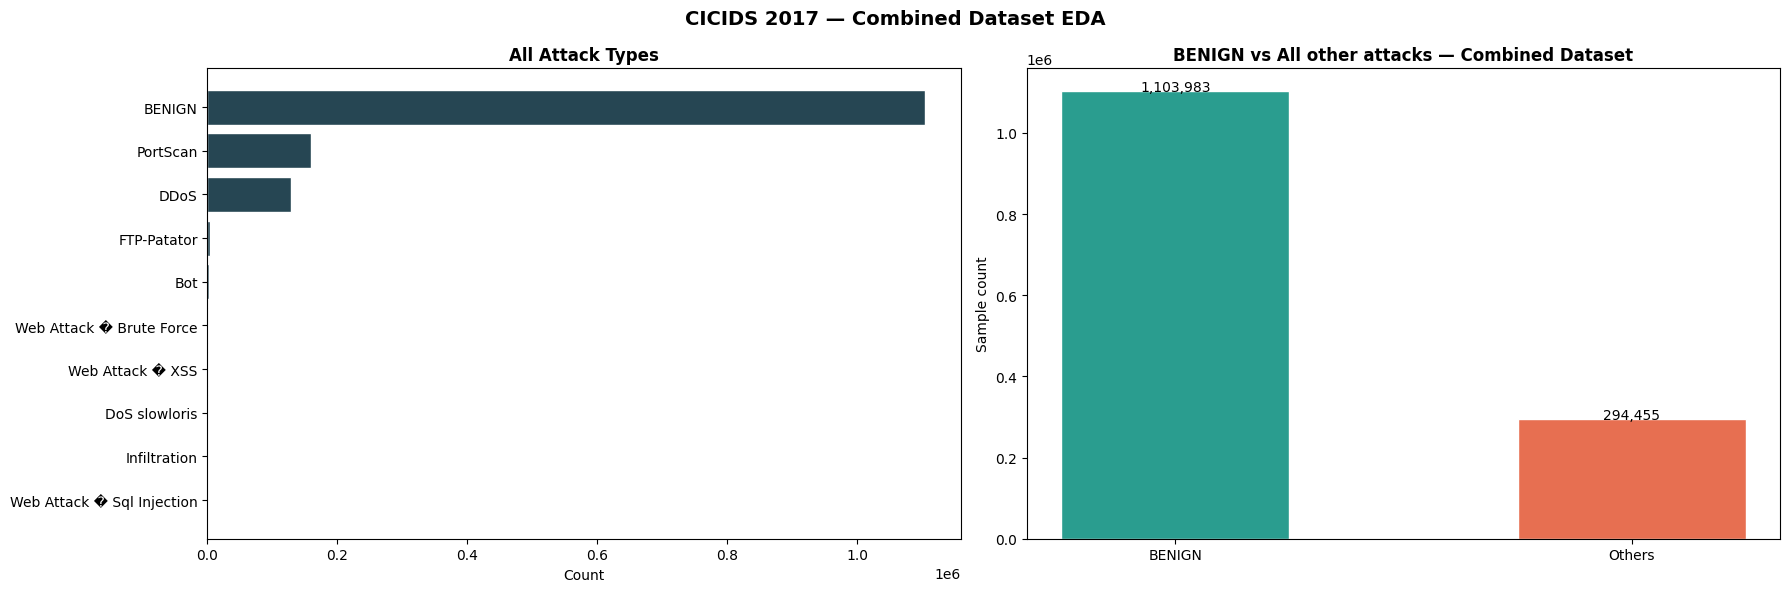

In [ ]:
# call the EDA function to perform EDA on the full combined dataset
perform_eda(df_raw)

In [ ]:
'''
This section processes the Wednesday data to focus on BENIGN and DoS attacks only.
All DoS variants are merged into a single 'DDoS' label for GAN training on BENIGN vs DDoS only.
'''

def process_wednesday(df_wed):
    
    # Define DoS attack labels to keep
    dos_labels = [
        'DoS Hulk',
        'DoS GoldenEye',
        'DoS slowloris',
        'DoS Slowhttptest'
    ]

    # Keep BENIGN and DDoS rows only
    df_filtered = df_wed[
        df_wed['Label'].isin(['BENIGN'] + dos_labels)
    ].copy()

    # Merge all DDoS variants into single DDoS label
    df_filtered['Label'] = df_filtered['Label'].apply(
        lambda x: 'DDoS' if x != 'BENIGN' else x
    )

    # Summary of wednesday file
    counts   = df_filtered['Label'].value_counts()
    total    = len(df_filtered)
    excluded = len(df_wed) - total

    print("Wednesday file After filtering:")
    print(f"Rows kept: {total:,}")
    print(f"Rows excluded : {excluded} (Heartbleed)")
    print(f"{'Label':<10} {'Count':>8}  {'%':>6}")
    print(f"{'-'*28}")
    for label, count in counts.items():
        print(f"{label:<10} {count:>8,}  {count/total*100:>5.1f}%")

    # Plot
    plt.figure(figsize=(7, 4))
    bars = plt.bar(counts.index, counts.values,
                   color=['#2A9D8F', '#E76F51'],
                   edgecolor='white', width=0.4)
    plt.ylabel("count")
    plt.title("Wednesday — BENIGN vs DDoS (GAN Training Data)",
              fontweight='bold')
    for bar, val in zip(bars, counts.values):
        plt.text(bar.get_x() + bar.get_width() / 2,
                 val + 200, f'{val:,}', ha='center', fontsize=10)
    plt.tight_layout()
    plt.show()

    return df_filtered

Wednesday file After filtering:
Rows kept: 27,779
Rows excluded : 1 (Heartbleed)
Label         Count       %
----------------------------
BENIGN       27,626   99.4%
DDoS            153    0.6%


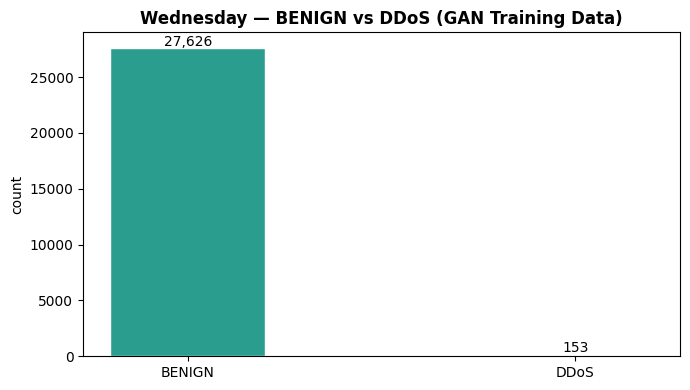

In [17]:
# Extract preprocessed wednesday file
df_wednesday_gan = process_wednesday(df_wed)

In [ ]:
'''
This function cleans the data by replacing infinite values with NaN, imputing missing values with the
column median, and removing zero-variance columns that carry no information for GAN training.
'''

def clean_data(df, label_col="Label"):
    
    # Separate features and labels
    feature_cols = [col for col in df.columns if col != label_col]
    X = df[feature_cols].copy()

    # Replace inf with NaN then impute with column median
    X.replace([np.inf, -np.inf], np.nan, inplace=True)
    X.fillna(X.median(numeric_only=True), inplace=True)

    # Remove zero-variance columns (carry no information for GAN)
    X = X.loc[:, X.std() > 0]
    print(f"  Features after removing zero-variance: {X.shape[1]}")

    return X, X.shape

In [ ]:
''' Preprocess data for GAN training '''

def preprocess_data(df, label_col="Label"):
    
    # Extract labels BEFORE clean_data removes the label column
    le = LabelEncoder()
    y  = le.fit_transform(df[label_col])
    print(f"  Label encoding: {dict(zip(le.classes_, range(len(le.classes_))))}")

    # Clean features
    X, _ = clean_data(df, label_col)

    # Standardise to zero mean, unit variance
    scaler   = StandardScaler()
    X_scaled = scaler.fit_transform(X.values.astype(np.float32))

    print(f"  Final shape: {X_scaled.shape}")
    return X_scaled, y

In [20]:
# Preprocess the wednesday data
X_scaled, y = preprocess_data(df_wednesday_gan)

  Label encoding: {'BENIGN': 0, 'DDoS': 1}
  Features after removing zero-variance: 68
  Final shape: (27779, 68)


In [21]:
# Set N_FEATURES from the cleaned data
N_FEATURES = X_scaled.shape[1]
print(f"N_FEATURES = {N_FEATURES}")

N_FEATURES = 68


In [22]:
# Data loading section
train_dataset = TensorDataset(
    torch.FloatTensor(X_scaled),
    torch.LongTensor(y)
)
dataloader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True
)

In [ ]:
# Define the Generator model
class Generator(nn.Module):
    def __init__(self, noise_dim=NOISE_DIM, output_dim=N_FEATURES):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(noise_dim, 256),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(0.2),

            nn.Linear(256, 512),
            nn.BatchNorm1d(512),
            nn.LeakyReLU(0.2),

            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(0.2),

            nn.Linear(256, output_dim)
        )

    def forward(self, z):
        return self.net(z)

In [ ]:
# Define the Discriminator model, dropout is added to prevent overfitting and ensure training stability.
class Discriminator(nn.Module):
    """
    Fully-connected Discriminator for tabular data.

    Maps feature vector (N_FEATURES) -> real/fake probability.

    Design choices:
      - Dropout(0.3): regularises the discriminator to prevent it from
        becoming too powerful too quickly — a common GAN failure mode
        where D wins easily and G receives no useful gradient signal
      - LeakyReLU: standard choice for discriminators (same as DCGAN)
      - Sigmoid output: produces probability in [0,1] for BCELoss
    """
    def __init__(self, noise_dim=N_FEATURES):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(noise_dim, 256),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.5),

            nn.Linear(256, 256),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.5),

            nn.Linear(256, 128),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),

            nn.Linear(128, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

In [ ]:
# Training function for the GAN
def train_cyber_gan(dataloader, num_epochs=N_EPOCHS,
                    g_lr=G_LR, d_lr=D_LR, device=device):
  
    # Instantiate models
    gen  = Generator().to(device)
    disc = Discriminator().to(device)

    # Separate optimisers — different learning rates
    opt_gen  = optim.Adam(gen.parameters(),  lr=g_lr, betas=(0.5, 0.999))
    opt_disc = optim.Adam(disc.parameters(), lr=d_lr, betas=(0.5, 0.999))
    criterion = nn.BCELoss()

    # Track losses for plotting
    gen_losses, disc_losses = [], []

    print(f"GAN training started")

    # Training loop
    for epoch in range(num_epochs):
        total_gen_loss, total_disc_loss = [], []

        for real, _ in dataloader:
            real       = real.to(device)
            batch_size = real.shape[0]

            real_labels = torch.ones(batch_size, 1).to(device) * 0.9
            fake_labels = torch.zeros(batch_size, 1).to(device)

            # Discriminator step
            opt_disc.zero_grad()

            # Loss on real samples
            loss_disc_real = criterion(disc(real), real_labels)

            # Loss on fake samples
            noise = torch.randn(batch_size, NOISE_DIM).to(device)
            fake  = gen(noise).detach()
            loss_disc_fake = criterion(disc(fake), fake_labels)

            loss_disc = (loss_disc_real + loss_disc_fake) / 2
            loss_disc.backward()
            opt_disc.step()

            # Generator step
            opt_gen.zero_grad()
            noise    = torch.randn(batch_size, NOISE_DIM).to(device)
            fake     = gen(noise)
            loss_gen = criterion(disc(fake),
                                        torch.ones(batch_size, 1).to(device))
            loss_gen.backward()
            opt_gen.step()

            # Record losses for this batch
            total_gen_loss.append(loss_gen.item())
            total_disc_loss.append(loss_disc.item())

        # Average losses for this epoch
        gen_losses.append(np.mean(total_gen_loss))
        disc_losses.append(np.mean(total_disc_loss))

        if (epoch + 1) % 10 == 0:
          print(
                f"Epoch [{epoch+1:3d}/{num_epochs}] | D Loss: {disc_losses[-1]:.4f} | G Loss: {gen_losses[-1]:.4f}"
            )

    # Loss plot
    plt.figure(figsize=(10, 5))
    plt.plot(gen_losses,  label="Generator", color="#E76F51", linewidth=2)
    plt.plot(disc_losses, label="Discriminator", color="#2A9D8F", linewidth=2)
    plt.xlabel("Epoch")
    plt.ylabel("BCE Loss")
    plt.title("Training Losses (Wednesday: BENIGN vs DoS)")
    plt.legend()
    plt.tight_layout()
    plt.show()

    return gen, disc

GAN training started
Epoch [ 10/100] | D Loss: 0.4048 | G Loss: 2.1880
Epoch [ 20/100] | D Loss: 0.3939 | G Loss: 2.2164
Epoch [ 30/100] | D Loss: 0.3679 | G Loss: 2.5945
Epoch [ 40/100] | D Loss: 0.3494 | G Loss: 2.8308
Epoch [ 50/100] | D Loss: 0.3485 | G Loss: 2.9261
Epoch [ 60/100] | D Loss: 0.3457 | G Loss: 2.9012
Epoch [ 70/100] | D Loss: 0.3549 | G Loss: 2.8026
Epoch [ 80/100] | D Loss: 0.3561 | G Loss: 2.7842
Epoch [ 90/100] | D Loss: 0.3613 | G Loss: 2.7725
Epoch [100/100] | D Loss: 0.3607 | G Loss: 2.7381


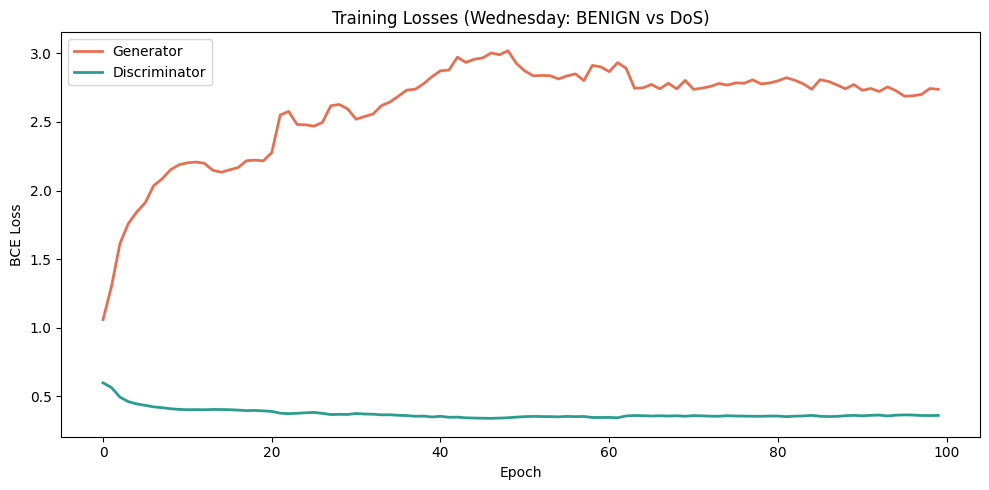

In [ ]:
# Train the GAN on the preprocessed Wednesday data
generator, discriminator = train_cyber_gan(dataloader,g_lr=0.0001,d_lr=0.0005)

In [ ]:
'''
This function visualises the real and generated feature vectors using t-SNE. 
It generates fake samples from the trained generator, samples real data, and 
fits t-SNE on the combined dataset to project both real and fake samples into the same 2D space. 
The resulting plot shows how well the generator has learned the data distribution.
'''

def visualise_with_tsne(generator, X_scaled, n_samples=2000,
                        perplexity=30, device=device):
    
    # Generate fake samples
    generator.eval()
    with torch.no_grad():
        noise   = torch.randn(n_samples, NOISE_DIM).to(device)
        fake_np = generator(noise).cpu().numpy()
    generator.train()

    # Sample real data
    idx_vis = np.random.choice(len(X_scaled), n_samples, replace=False)
    real_np = X_scaled[idx_vis]

    # Fit t-SNE on combined data
    combined = np.vstack([real_np, fake_np])
    print(f"t-SNE on {len(combined):,} samples")

    # Fit t-SNE on combined data
    tsne = TSNE(n_components=2, perplexity=perplexity,
                       random_state=SEED, n_iter=1000, verbose=0)
    
    # Transform the combined dataset
    tsne_result = tsne.fit_transform(combined)

    # Split back into real and generated
    real_tsne = tsne_result[:n_samples]
    fake_tsne = tsne_result[n_samples:]

    # Plot for real and generated data
    plt.figure(figsize=(10, 8))
    plt.scatter(real_tsne[:, 0], real_tsne[:, 1],
                alpha=0.3, s=6, color='#264653', label='Real Network Traffic')
    plt.scatter(fake_tsne[:, 0], fake_tsne[:, 1],
                alpha=0.3, s=6, color='#E76F51', label='Generated Network Traffic')

    plt.title("t-SNE: Real vs Generated Traffic",
              fontsize=14, fontweight='bold')
    plt.xlabel("t-SNE Dim 1")
    plt.ylabel("t-SNE Dim 2")
    plt.legend()
    plt.tight_layout()
    plt.show()

    print("t-SNE complete.")
    return real_tsne, fake_tsne, real_np, fake_np

In [ ]:
'''This function compares real and generated distributions at the per-feature level.
It computes mean absolute error (MAE) between real and generated per-feature means and standard deviations.
'''

def evaluate_feature_statistics(real_np, fake_np, n_show=30):
    
    # Compute per-feature statistics
    real_mean = real_np.mean(axis=0)
    fake_mean = fake_np.mean(axis=0)
    real_std  = real_np.std(axis=0)
    fake_std  = fake_np.std(axis=0)

    # Compute mean absolute errors for means
    mean_error = np.abs(real_mean - fake_mean).mean()
    
    # Compute mean absolute error for std deviations
    std_error  = np.abs(real_std  - fake_std ).mean()

    # Print summary table
    print(f"  {'Metric':<40} {'Value':>10}")
    print(f"  {'-'*52}")
    print(f"  {'MAE in per-feature means':<40} {mean_error:>10.4f}")
    print(f"  {'MAE in per-feature stds':<40} {std_error:>10.4f}")


    #  store KS test results for all features
    ks_stats, ks_pvals = [], []
    
    # Run KS test for each feature
    for i in range(real_np.shape[1]):
        stat, pval = ss.ks_2samp(real_np[:, i], fake_np[:, i])
        ks_stats.append(stat)
        ks_pvals.append(pval)

    # Convert to numpy arrays for analysis
    ks_stats = np.array(ks_stats)
    ks_pvals = np.array(ks_pvals)

    # % of features where distributions are not significantly different (i.e: p > 0.05)
    pct_pass = (ks_pvals > 0.05).mean() * 100

    print(f"{'Mean KS statistic (all features)':<40} {ks_stats.mean():>10.4f}")
    print(f"{'Features passing KS test (p>0.05)':<40} {pct_pass:>9.1f}%")
    print(f"Mean KS = {ks_stats.mean():.4f}")

    # Side by side bar charts
    n_show = min(n_show, real_np.shape[1])
    x_ax   = np.arange(n_show)
    width  = 0.4

    fig, axes = plt.subplots(1, 2, figsize=(18, 5))

    # Mean comparison
    axes[0].bar(x_ax - width/2, real_mean[:n_show], width,
                label='Real',      color='#264653', alpha=0.8)
    axes[0].bar(x_ax + width/2, fake_mean[:n_show], width,
                label='Generated', color='#E76F51', alpha=0.8)
    axes[0].set_title(f"Per-Feature Mean (first {n_show} features)")
    axes[0].set_xlabel("Feature index")
    axes[0].set_ylabel("Mean")
    axes[0].legend()

    # Std comparison
    axes[1].bar(x_ax - width/2, real_std[:n_show], width,
                label='Real',      color='#264653', alpha=0.8)
    axes[1].bar(x_ax + width/2, fake_std[:n_show], width,
                label='Generated', color='#E76F51', alpha=0.8)
    axes[1].set_title(f"Per-Feature Std (first {n_show} features)")
    axes[1].set_xlabel("Feature index")
    axes[1].set_ylabel("Std")
    axes[1].legend()

    fig.suptitle("CICIDS GAN — Feature Statistics: Real vs Generated",
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    return mean_error, std_error, ks_stats.mean(), pct_pass

In [ ]:
'''
This function runs the full evaluation of the trained CICIDS tabular GAN 
by combining t-SNE visualisation and per-feature statistics comparison functions.
'''

def evaluate_gan(generator, X_scaled, n_samples=2000,
                 perplexity=30, device=device):

    # t-SNE visualisation
    print("t-SNE Visualisation")
    print("-" * 38)
    real_tsne, fake_tsne, real_np, fake_np = visualise_with_tsne(
        generator, X_scaled,
        n_samples=n_samples,
        perplexity=perplexity,
        device=device
    )

    # Feature statistics
    mean_err, std_err, _, _ = evaluate_feature_statistics(real_np, fake_np)

    # Summary
    print("\n")
    print("Evaluation Summary")
    print("\n")
    print(f"  Mean MAE : {mean_err:.4f} \n")
    print(f"Std  MAE : {std_err:.4f}")

t-SNE Visualisation
--------------------------------------
t-SNE on 4,000 samples


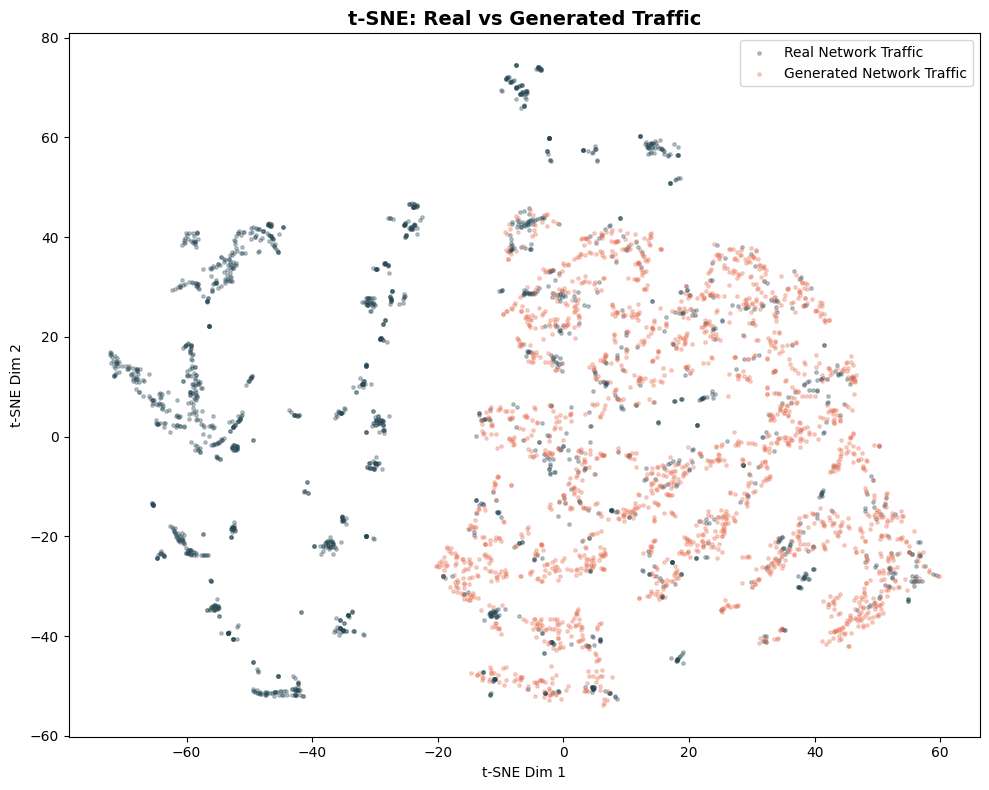

t-SNE complete.
  Metric                                        Value
  ----------------------------------------------------
  MAE in per-feature means                     0.2817
  MAE in per-feature stds                      0.5234
Mean KS statistic (all features)             0.4741
Features passing KS test (p>0.05)              0.0%
Mean KS = 0.4741


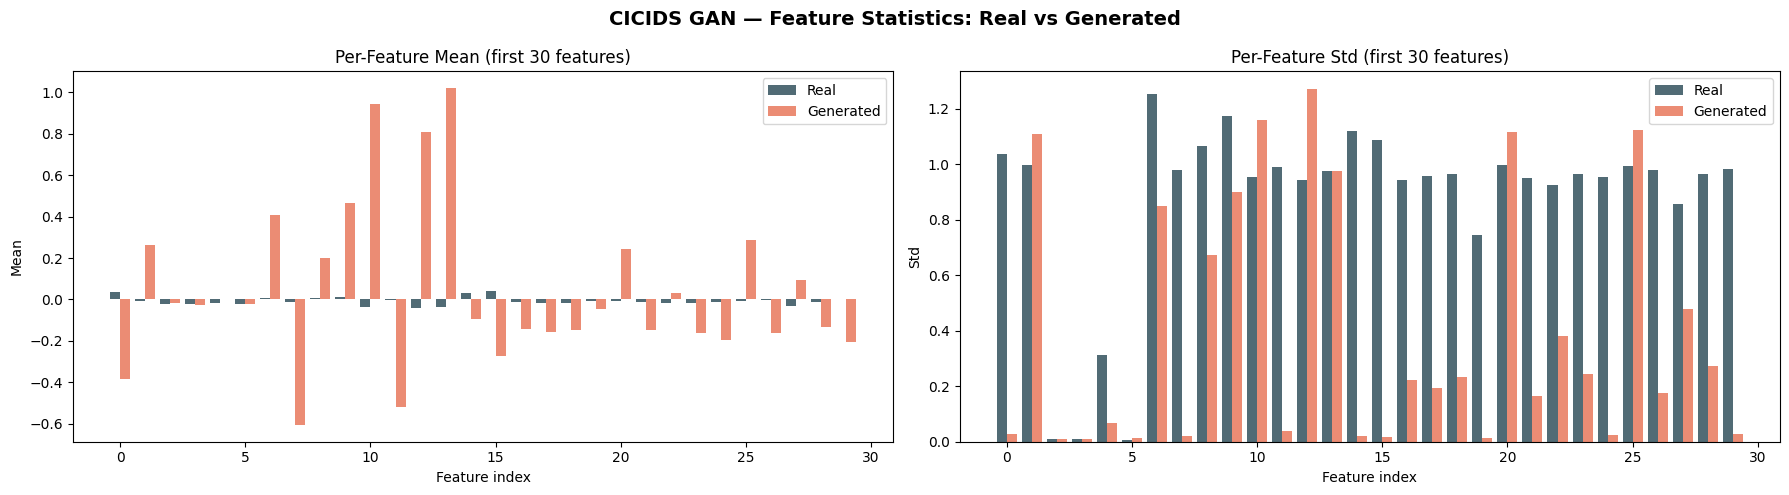



Evaluation Summary


  Mean MAE : 0.2817 

Std  MAE : 0.5234


In [30]:
# Run Full Evaluation
evaluate_gan(generator, X_scaled)